In [14]:
from torchvision import datasets
import torch
data_folder = '^/data/FMNIST'
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 271kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.02MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.9MB/s]


In [15]:
tr_images = fmnist.data
tr_targets = fmnist.targets

In [17]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

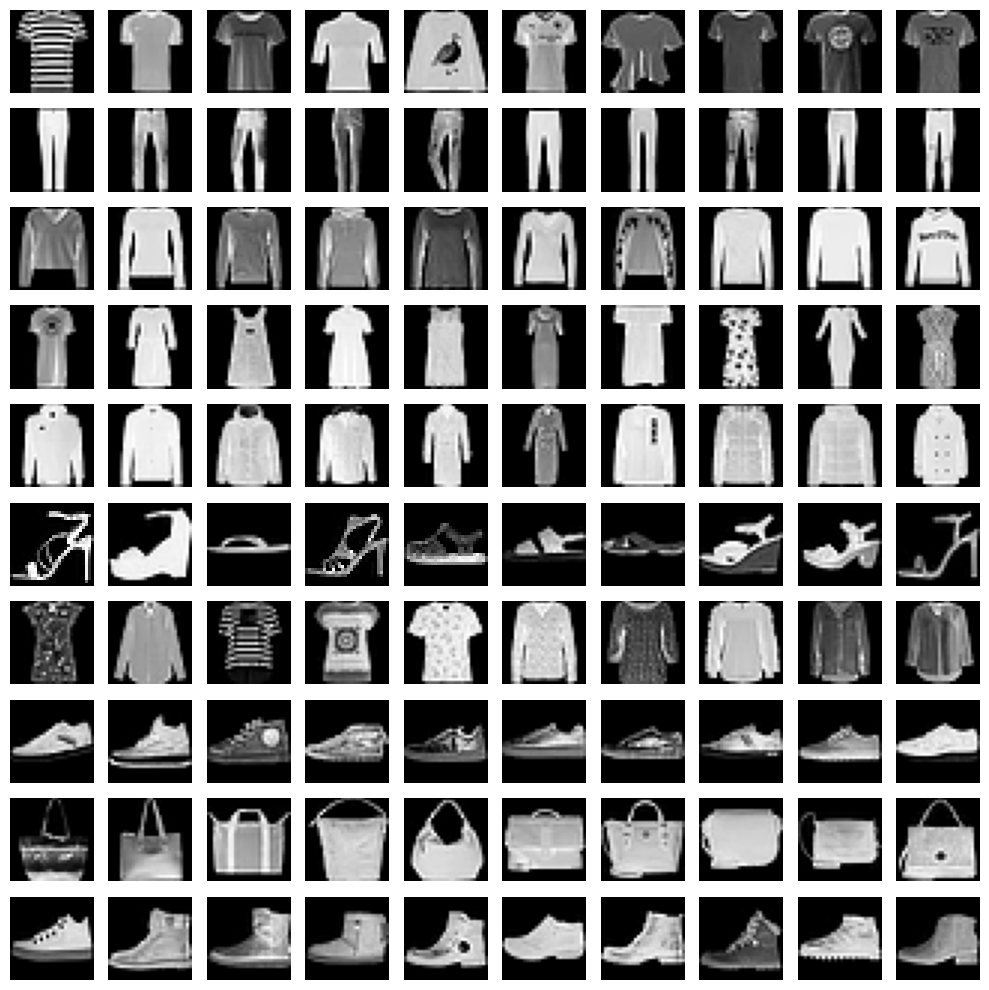

In [18]:
R, C = len(tr_targets.unique()), 10  # R = número de classes distintas, C = 10 exemplos por classe
fig, ax = plt.subplots(R, C, figsize=(10,10))
for label_class, plot_row in enumerate(ax):
  label_x_rows = np.where(tr_targets == label_class)[0]  # pega os índices de todas as imagens dessa classe
  for plot_cell in plot_row:
    plot_cell.grid(False); plot_cell.axis('off')
    ix = np.random.choice(label_x_rows)  # sorteia uma imagem aleatória daquela classe
    x, y = tr_images[ix], tr_targets[ix]
    plot_cell.imshow(tr_images[ix], cmap='gray')
plt.tight_layout()  # grid pra visualizar exemplos de cada classe do dataset

In [19]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
device = 'cuda' if torch.cuda.is_available() else 'cpu'
from torchvision import datasets

In [ ]:
class FMNISTDataset(Dataset):
  def __init__(self,x,y):
    x = x.float()
    x = x.view(-1, 28*28)  # achata a imagem
    self.x, self.y = x, y
  def __getitem__(self, idx):
    x, y = self.x[idx], self.y[idx]
    return x.to(device), y.to(device)
  def __len__(self):
    return len(self.x)

In [37]:
def get_data():
  train = FMNISTDataset(tr_images, tr_targets)
  trn_dl = DataLoader(train, batch_size=32, shuffle=True)
  return trn_dl

In [ ]:
from torch.optim import SGD
def get_model():
   model = nn.Sequential(
       nn.Linear(28*28, 1000),
       nn.ReLU(),
       nn.Linear(1000, 10)  # aqui só uma camada oculta
   ).to(device)
   loss_fn = nn.CrossEntropyLoss()
   optimizer = SGD(model.parameters(), lr=1e-2)  # usando SGD em vez de Adam aqui
   return model, loss_fn, optimizer

In [39]:
@torch.no_grad()
def accuracy(x, y, model):
  model.eval()
  prediction = model(x)
  max_values, argmaxes = prediction.max(-1)
  is_correct = argmaxes == y
  return is_correct.cpu().numpy().tolist()

In [40]:
def train_batch(x, y, model, opt, loss_fn):
  model.train()
  prediction = model(x)
  batch_loss = loss_fn(prediction, y)
  batch_loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  return batch_loss.item()

In [41]:
trn_dl = get_data()
model, loss_fn, optimizer = get_model()

In [42]:
losses, accuracies = [], []
for epoch in range(5):
  print(epoch)
  epoch_losses, epoch_accuracies = [], []
  for ix, batch in enumerate(iter(trn_dl)):
    x, y = batch
    batch_loss = train_batch(x, y, model, optimizer, loss_fn)
    epoch_losses.append(batch_loss)
  epoch_loss = np.array(epoch_losses).mean()
  for i, batch in enumerate(iter(trn_dl)):
    x, y = batch
    is_correct = accuracy(x, y, model)
    epoch_accuracies.extend(is_correct)
  epoch_accuracy = np.mean(epoch_accuracies)
  losses.append(epoch_loss)
  accuracies.append(epoch_accuracy)

0
1
2
3
4


/tmp/ipykernel_4039/2997995267.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


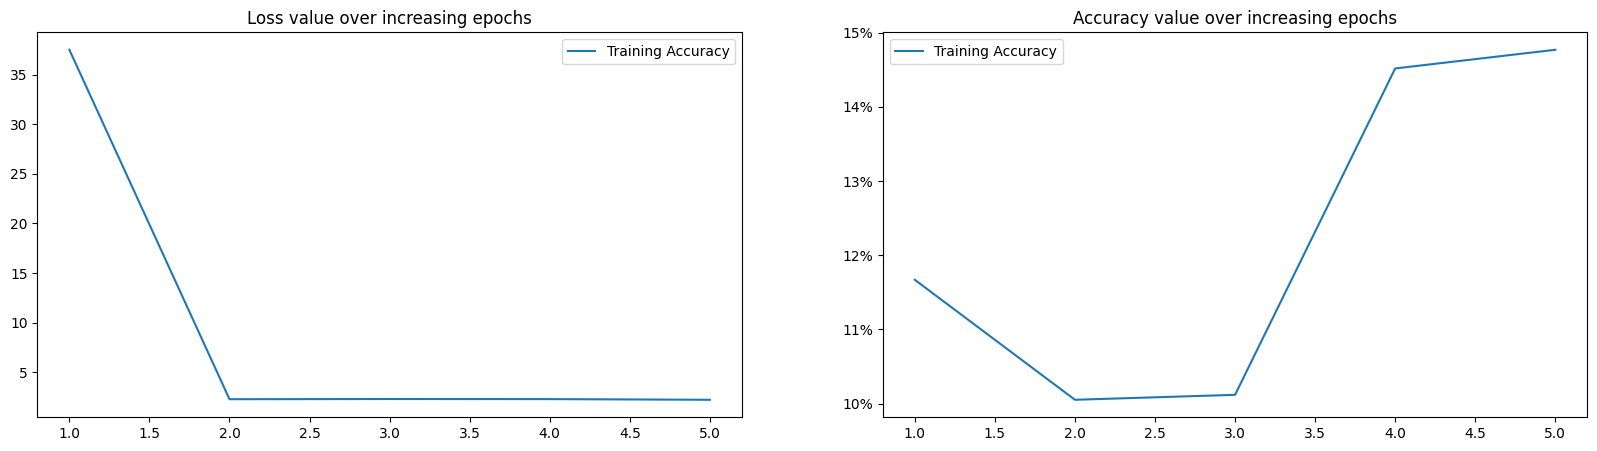

In [44]:
epochs = np.arange(5)+1
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Accuracy')
plt.legend()
plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])  # só formata o eixo y como porcentagem
plt.legend()